In [1]:
import numpy as np
import MDAnalysis as mda
from scipy.spatial import distance
import os
from tqdm import tqdm

/Users/jlee295/miniconda3/envs/pyemma/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# System definitions
systems = {
    "H3":                        {"entry": (786, 839), "exit": (295, 348)},
    "cenpa":                     {"entry": (790, 842), "exit": (295, 347)},
    "ltH3core":                  {"entry": (785, 837), "exit": (295, 347)},
    "ltcenpacore":               {"entry": (791, 844), "exit": (295, 348)},
    "thruhelixH3":               {"entry": (785, 837), "exit": (295, 347)},
    "thruhelixcenpa":            {"entry": (791, 844), "exit": (295, 348)},
    "H3withcenpahelix":          {"entry": (786, 839), "exit": (295, 348)},
    "cenpawithH3helix":          {"entry": (790, 842), "exit": (295, 347)},
    "stH3core":                  {"entry": (785, 837), "exit": (295, 347)},
    "stcenpacore":               {"entry": (791, 844), "exit": (295, 348)},
    "H3withcenpalatch":          {"entry": (786, 839), "exit": (295, 348)},
    "cenpawithH3latch":          {"entry": (790, 842), "exit": (295, 347)},
    "H3withcenpa_latch_helix":   {"entry": (786, 839), "exit": (295, 348)},
    "cenpawithH3_latch_helix":   {"entry": (790, 842), "exit": (295, 347)},
}

cutoff = 8.0
replica_size = 80004
n_replicas = 4
skip = 10

def compute_contacts(u, residue_range):

    dna = u.select_atoms("resid 1:294")
    results = {}

    for resid in tqdm(range(residue_range[0], residue_range[1] + 1), desc="Residues"):

        tail = u.select_atoms(f"resid {resid} and name CA")

        if len(tail) == 0:
            continue

        replica_means = []

        for rep in range(n_replicas):

            start = rep * replica_size
            stop  = (rep + 1) * replica_size

            contact_sum = 0

            for ts in u.trajectory[start:stop:skip]:

                d = distance.cdist(dna.positions, tail.positions)
                contact_sum += np.sum(d < cutoff)

            replica_means.append(contact_sum / (replica_size/skip))

        replica_means = np.array(replica_means)

        mean = np.mean(replica_means)
        sem  = np.std(replica_means, ddof=1) / np.sqrt(n_replicas)

        results[resid] = (mean, sem)

    return results


# Loop over systems
for system, tails in systems.items():

    print(f"Processing {system}...")

    if system in ["H3", "cenpa", "ltH3core", "ltcenpacore", "thruhelixH3", "thruhelixcenpa", "H3withcenpahelix", "cenpawithH3helix", "stH3core", "stcenpacore", "H3withcenpalatch", "cenpawithH3latch", "H3withcenpa_latch_helix", "cenpawithH3_latch_helix"]:
        pdb_file = os.path.join(system, f"min_{system}_renumresidues.pdb")

    xtc_file = os.path.join(system, "combined_aligned.dcd")

    if not os.path.exists(pdb_file):
        print(f"WARNING: Missing {pdb_file}, skipping.")
        continue

    u = mda.Universe(pdb_file, xtc_file)

    entry_results = compute_contacts(u, tails["entry"])
    exit_results  = compute_contacts(u, tails["exit"])

    entry_file = os.path.join(system, f"{system}_entry_tail_contacts.dat")
    exit_file  = os.path.join(system, f"{system}_exit_tail_contacts.dat")

    with open(entry_file, "w") as f:
        f.write("#Resid  MeanContacts  SEM\n")
        for resid, (mean, sem) in entry_results.items():
            f.write(f"{resid} {mean:.6f} {sem:.6f}\n")

    with open(exit_file, "w") as f:
        f.write("#Resid  MeanContacts  SEM\n")
        for resid, (mean, sem) in exit_results.items():
            f.write(f"{resid} {mean:.6f} {sem:.6f}\n")

    print(f"{system} done. Files written inside {system}/\n")

Processing H3...


Residues: 100%|██████████| 54/54 [02:56<00:00,  3.26s/it]


H3 done. Files written inside H3/

Processing cenpa...


Residues: 100%|██████████| 53/53 [02:53<00:00,  3.27s/it]


cenpa done. Files written inside cenpa/

Processing ltH3core...


...

cenpawithH3latch done. Files written inside cenpawithH3latch/

Processing H3withcenpa_latch_helix...


Residues: 100%|██████████| 54/54 [03:00<00:00,  3.35s/it]


H3withcenpa_latch_helix done. Files written inside H3withcenpa_latch_helix/

Processing cenpawithH3_latch_helix...


Residues: 100%|██████████| 53/53 [02:56<00:00,  3.33s/it]

cenpawithH3_latch_helix done. Files written inside cenpawithH3_latch_helix/



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

width = 0.28  # bar width

# -----------------------------
# Residue sequences (trimmed)
# -----------------------------
listH3 = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
          'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
          'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
          'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
          'Y41','R42','P43','G44','T45','V46','A47','L48','R49','E50',
          'I51','R52','R53','Y54']

listcenpa = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
             'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
             'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
             'S31','L32','G33','A34','S35','S36','H37','Q38','H39','S40',
             'R41','R42','R43','Q44','G45','W46','L47','K48','E49','I50',
             'R51','K52','L53']

listltH3core = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
                'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
                'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
                'S31','L32','G33','A34','S35','S36','H37','Q38','H39','S40',
                'R41','R42','R43','T44','V45','A46','L47','R48','E49','I50',
                'R51','R52','Y53']

listltcenpacore = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
                   'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
                   'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
                   'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
                   'Y41','R42','P43','G44','Q45','G46','W47','L48','K49','E50',
                   'I51','R52','K53','L54']

listthruhelixH3 = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
                   'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
                   'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
                   'S31','L32','G33','A34','S35','S36','H37','Q38','H39','S40',
                   'R41','R42','R43','Q44','G45','W46','L47','K48','E49','I50',
                   'R51','K52','L53']

listthruhelixcenpa = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
                      'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
                      'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
                      'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
                      'Y41','R42','P43','G44','T45','V46','A47','L48','R49','E50',
                      'I51','R52','R53','Y54']

listH3withcenpahelix = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
                        'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
                        'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
                        'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
                        'Y41','R42','P43','G44','Q45','G46','W47','L48','K49','E50',
                        'I51','R52','K53','L54']

listcenpawithH3helix = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
                        'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
                        'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
                        'S31','L32','G33','A34','S35','S36','H37','Q38','H39','S40',
                        'R41','R42','R43','T44','V45','A46','L47','R48','E49','I50',
                        'R51','R52','Y53']

liststH3core = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
                'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
                'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
                'S31','L32','G33','A34','S35','S36','P37','H38','R39','Y40',
                'R41','P42','G43','T44','V45','A46','L47','R48','E49','I50',
                'R51','R52','Y53']

liststcenpacore = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
                   'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
                   'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
                   'A31','T32','G33','G34','V35','K36','K37','H38','Q39','H40',
                   'S41','R42','R43','R44','Q45','G46','W47','L48','K49','E50',
                   'I51','R52','K53','L54']

listH3withcenpalatch = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
                        'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
                        'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
                        'A31','T32','G33','G34','V35','K36','K37','H38','Q39','H40',
                        'S41','R42','R43','R44','T45','V46','A47','L48','R49','E50',
                        'I51','R52','R53','Y54']

listcenpawithH3latch = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
                        'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
                        'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
                        'S31','L32','G33','A34','S35','S36','P37','H38','R39','Y40',
                        'R41','P42','G43','Q44','G45','W46','L47','K48','E49','I50',
                        'R51','K52','L53']

listH3withcenpa_latch_helix = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
                               'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
                               'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
                               'A31','T32','G33','G34','V35','K36','K37','H38','Q39','H40',
                               'S41','R42','R43','R44','Q45','G46','W47','L48','K49','E50',
                               'I51','R52','K53','L54']

listcenpawithH3_latch_helix = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
                               'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
                               'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
                               'S31','L32','G33','A34','S35','S36','P37','H38','R39','Y40',
                               'R41','P42','G43','T44','V45','A46','L47','R48','E49','I50',
                               'R51','R52','Y53']

In [80]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# Systems
# -----------------------------
systems = [
    "H3", "cenpa", "ltH3core", "ltcenpacore",
    "thruhelixH3", "thruhelixcenpa",
    "H3withcenpahelix", "cenpawithH3helix",
    "stH3core", "stcenpacore",
    "H3withcenpalatch", "cenpawithH3latch",
    "H3withcenpa_latch_helix", "cenpawithH3_latch_helix"
]

# -----------------------------
# Region definitions
# format: (range1, range2)
# -----------------------------
regions = {
    "H3": {
        "tails": [(295,331), (786,822)],
        "latch": [(332,338), (823,829)],
        "alphaN": [(339,348), (830,839)]
    },
    "cenpa": {
        "tails": [(295,330), (790,825)],
        "latch": [(331,337), (826,832)],
        "alphaN": [(338,347), (833,842)]
    },
    "ltH3core": {
        "tails": [(295,330), (785,820)],
        "latch": [(331,337), (821,827)],
        "alphaN": [(338,347), (828,837)]
    },
    "ltcenpacore": {
        "tails": [(295,331), (791,827)],
        "latch": [(332,338), (828,834)],
        "alphaN": [(339,348), (835,844)]
    },
    "thruhelixH3": {
        "tails": [(295,330), (785,820)],
        "latch": [(331,337), (821,827)],
        "alphaN": [(338,347), (828,837)]
    },
    "thruhelixcenpa": {
        "tails": [(295,331), (791,827)],
        "latch": [(332,338), (828,834)],
        "alphaN": [(339,348), (835,844)]
    },
    "H3withcenpahelix": {
        "tails": [(295,331), (786,822)],
        "latch": [(332,338), (823,829)],
        "alphaN": [(339,348), (830,839)]
    },
    "cenpawithH3helix": {
        "tails": [(295,330), (790,825)],
        "latch": [(331,337), (826,832)],
        "alphaN": [(338,347), (833,842)]
    },
    "stH3core": {
        "tails": [(295,330), (785,820)],
        "latch": [(331,337), (821,827)],
        "alphaN": [(338,347), (828,837)]
    },
    "stcenpacore": {
        "tails": [(295,331), (791,827)],
        "latch": [(332,338), (828,834)],
        "alphaN": [(339,348), (835,844)]
    },
    "H3withcenpalatch": {
        "tails": [(295,331), (786,822)],
        "latch": [(332,338), (823,829)],
        "alphaN": [(339,348), (830,839)]
    },
    "cenpawithH3latch": {
        "tails": [(295,330), (790,825)],
        "latch": [(331,337), (826,832)],
        "alphaN": [(338,347), (833,842)]
    },
    "H3withcenpa_latch_helix": {
        "tails": [(295,331), (786,822)],
        "latch": [(332,338), (823,829)],
        "alphaN": [(339,348), (830,839)]
    },
    "cenpawithH3_latch_helix": {
        "tails": [(295,330), (790,825)],
        "latch": [(331,337), (826,832)],
        "alphaN": [(338,347), (833,842)]
    }
}

# -----------------------------
# Helper: sum region
# -----------------------------
def compute_region(data, ranges):
    mask = np.zeros(len(data), dtype=bool)

    for start, end in ranges:
        mask |= (data[:,0] >= start) & (data[:,0] <= end)

    selected = data[mask]

    total_contacts = np.sum(selected[:,1])
    total_sem = np.sqrt(np.sum(selected[:,2]**2))

    return total_contacts, total_sem

# -----------------------------
# Main loop
# -----------------------------
results = []

for system in systems:
    for tail_type in ["entry", "exit"]:
        filepath = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")

        if not os.path.exists(filepath):
            continue

        data = np.loadtxt(filepath, comments="#")

        for region_name, ranges in regions[system].items():
            total, sem = compute_region(data, ranges)

            results.append([
                system,
                tail_type,
                region_name,
                total,
                sem
            ])

# -----------------------------
# Save output
# -----------------------------
df = pd.DataFrame(results, columns=[
    "System", "Tail", "Region", "TotalContacts", "SEM"
])

df.to_csv("cumulative_tail_contacts.dat", index=False, sep="\t")

print("Done! Output: cumulative_tail_contacts.dat")

Done! Output: cumulative_tail_contacts.dat


/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/4247008419.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/4247008419.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


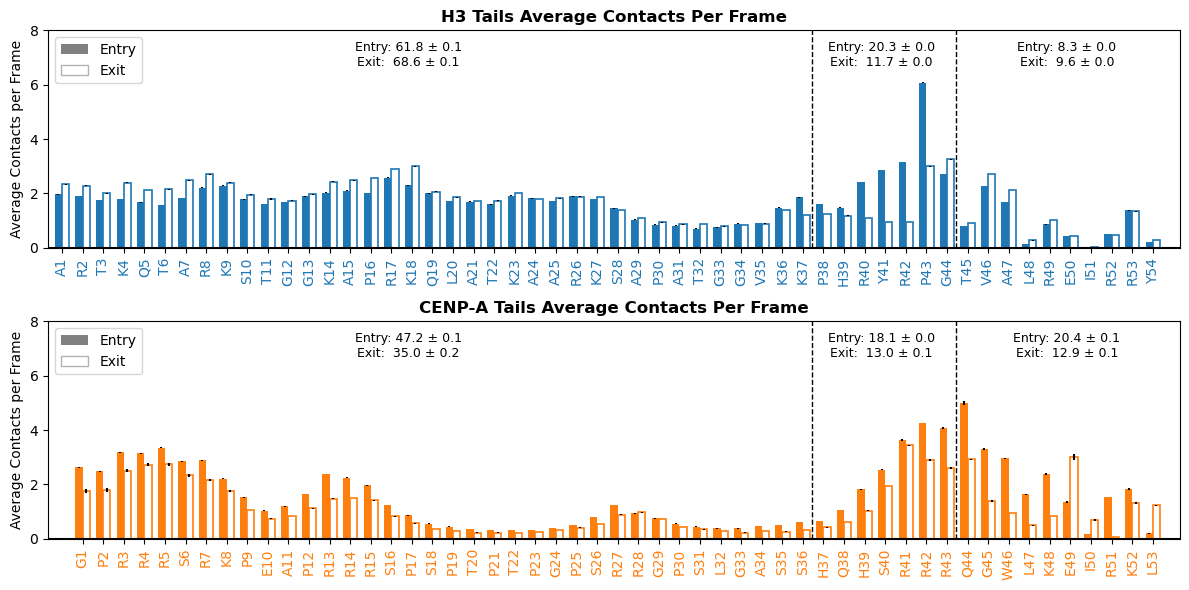

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None, subtitle=None,
                remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick handling
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        # Region centers
        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listH3) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_H3, ste_entry_H3 = load_tail_data("H3", "entry")
avg_exit_H3, ste_exit_H3 = load_tail_data("H3", "exit")

avg_entry_cenpa, ste_entry_cenpa = load_tail_data("cenpa", "entry")
avg_exit_cenpa, ste_exit_cenpa = load_tail_data("cenpa", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listH3)

# CENP-A padding
avg_entry_cenpa_plot = [0] + list(avg_entry_cenpa)
ste_entry_cenpa_plot = [0] + list(ste_entry_cenpa)
avg_exit_cenpa_plot = [0] + list(avg_exit_cenpa)
ste_exit_cenpa_plot = [0] + list(ste_exit_cenpa)
labels_cenpa_plot = [""] + list(listcenpa)

highlight_H3 = {}
highlight_cenpa = {}

# -----------------------------
# Generate figure
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# H3
plot_system(
    axes[0],
    avg_entry_H3, ste_entry_H3,
    avg_exit_H3, ste_exit_H3,
    listH3,
    tab20(0),
    subtitle="H3 Tails Average Contacts Per Frame",
    system_name="H3"
)

# CENP-A
plot_system(
    axes[1],
    avg_entry_cenpa_plot, ste_entry_cenpa_plot,
    avg_exit_cenpa_plot, ste_exit_cenpa_plot,
    labels_cenpa_plot,
    tab20(2),
    subtitle="CENP-A Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="cenpa"
)

plt.tight_layout()
plt.savefig('wildtype_CG_BYRES_CONTACTS.pdf')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/1042596781.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/1042596781.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


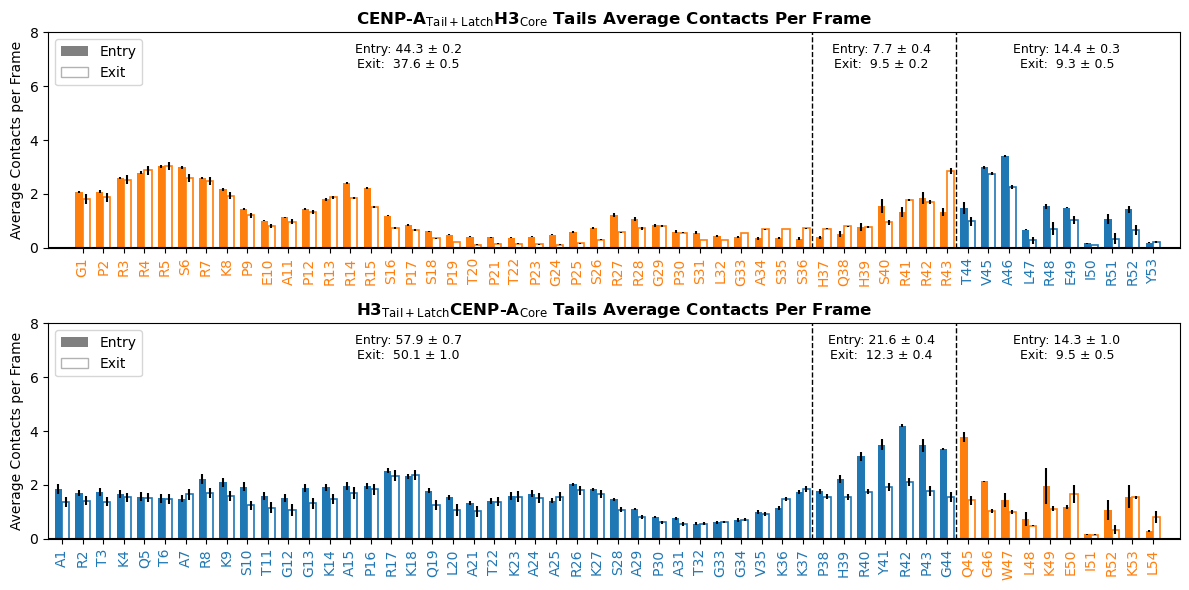

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick handling
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listltcenpacore) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_ltH3core, ste_entry_ltH3core = load_tail_data("ltH3core", "entry")
avg_exit_ltH3core, ste_exit_ltH3core = load_tail_data("ltH3core", "exit")

avg_entry_ltcenpacore, ste_entry_ltcenpacore = load_tail_data("ltcenpacore", "entry")
avg_exit_ltcenpacore, ste_exit_ltcenpacore = load_tail_data("ltcenpacore", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listltcenpacore)

# ltH3core (shift)
avg_entry_ltH3core_plot = [0] + list(avg_entry_ltH3core)
ste_entry_ltH3core_plot = [0] + list(ste_entry_ltH3core)
avg_exit_ltH3core_plot = [0] + list(avg_exit_ltH3core)
ste_exit_ltH3core_plot = [0] + list(ste_exit_ltH3core)
labels_ltH3core_plot = [""] + list(listltH3core)

# ltcenpacore
avg_entry_ltcenpacore_plot = list(avg_entry_ltcenpacore)
ste_entry_ltcenpacore_plot = list(ste_entry_ltcenpacore)
avg_exit_ltcenpacore_plot = list(avg_exit_ltcenpacore)
ste_exit_ltcenpacore_plot = list(ste_exit_ltcenpacore)
labels_ltcenpacore_plot = list(listltcenpacore)

highlight_ltH3core = {i: tab20(2) for i in range(1,44)}
highlight_ltcenpacore = {i: tab20(0) for i in range(0,44)}

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# ltH3core
plot_system(
    axes[0],
    avg_entry_ltH3core_plot, ste_entry_ltH3core_plot,
    avg_exit_ltH3core_plot, ste_exit_ltH3core_plot,
    labels_ltH3core_plot, tab20(0),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_ltH3core,
    subtitle=r"CENP-A$_{\mathrm{Tail+Latch}}$H3$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="ltH3core"
)

# ltcenpacore
plot_system(
    axes[1],
    avg_entry_ltcenpacore_plot, ste_entry_ltcenpacore_plot,
    avg_exit_ltcenpacore_plot, ste_exit_ltcenpacore_plot,
    labels_ltcenpacore_plot, tab20(2),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_ltcenpacore,
    subtitle=r"H3$_{\mathrm{Tail+Latch}}$CENP-A$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    system_name="ltcenpacore"
)

plt.tight_layout()
plt.savefig('tail+latch_CG_BYRES_CONTACTS.pdf')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/1407700704.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/1407700704.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


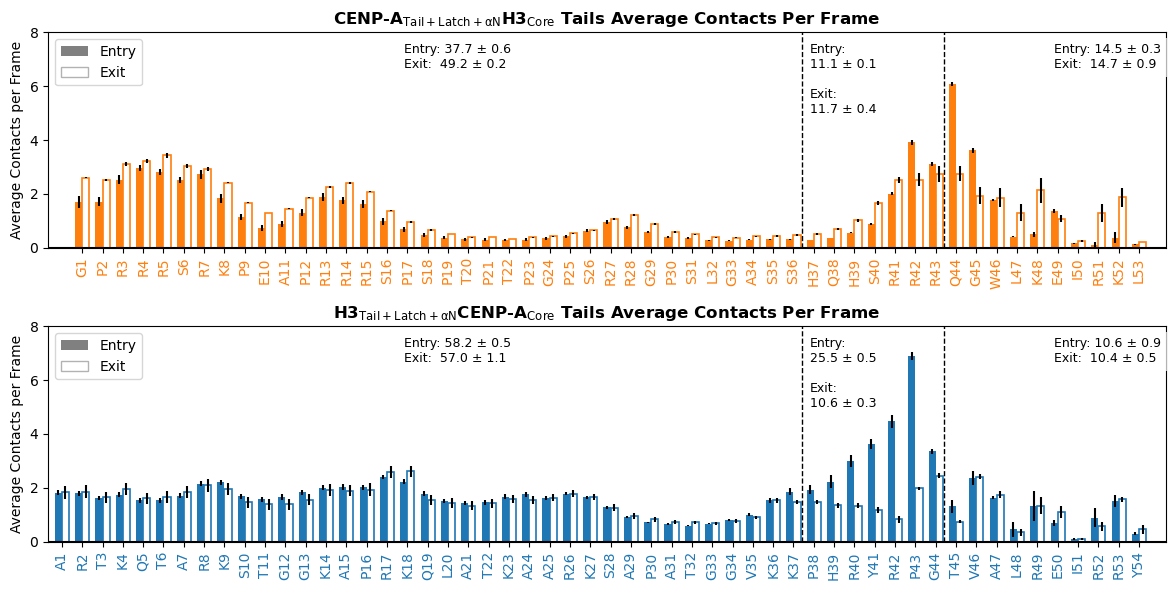

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick marks
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 38
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            if region == "latch":
                # Vertical format for latch only
                text = (
                    f"Entry:\n"
                    f"{entry_val:.1f} ± {entry_sem:.1f}\n\n"
                    f"Exit:\n"
                    f"{exit_val:.1f} ± {exit_sem:.1f}"
                )
            else:
                # Normal format for tails + helix
                text = (
                    f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                    f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
                )

            ax.text(
                xpos,
                y_top,
                text,
                ha='left',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listthruhelixcenpa) + 1.5)
# -----------------------------
# Load data
# -----------------------------
avg_entry_thruhelixH3, ste_entry_thruhelixH3 = load_tail_data("thruhelixH3", "entry")
avg_exit_thruhelixH3, ste_exit_thruhelixH3 = load_tail_data("thruhelixH3", "exit")

avg_entry_thruhelixcenpa, ste_entry_thruhelixcenpa = load_tail_data("thruhelixcenpa", "entry")
avg_exit_thruhelixcenpa, ste_exit_thruhelixcenpa = load_tail_data("thruhelixcenpa", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listthruhelixcenpa)

# thruhelixH3 (shift)
avg_entry_thruhelixH3_plot = [0] + list(avg_entry_thruhelixH3)
ste_entry_thruhelixH3_plot = [0] + list(ste_entry_thruhelixH3)
avg_exit_thruhelixH3_plot = [0] + list(avg_exit_thruhelixH3)
ste_exit_thruhelixH3_plot = [0] + list(ste_exit_thruhelixH3)
labels_thruhelixH3_plot = [""] + list(listthruhelixH3)

# thruhelixcenpa
avg_entry_thruhelixcenpa_plot = list(avg_entry_thruhelixcenpa)
ste_entry_thruhelixcenpa_plot = list(ste_entry_thruhelixcenpa)
avg_exit_thruhelixcenpa_plot = list(avg_exit_thruhelixcenpa)
ste_exit_thruhelixcenpa_plot = list(ste_exit_thruhelixcenpa)
labels_thruhelixcenpa_plot = list(listthruhelixcenpa)

highlight_thruhelixH3 = {i: tab20(2) for i in range(1,54)}
highlight_thruhelixcenpa = {i: tab20(0) for i in range(0,54)}

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# thruhelixH3
plot_system(
    axes[0],
    avg_entry_thruhelixH3_plot, ste_entry_thruhelixH3_plot,
    avg_exit_thruhelixH3_plot, ste_exit_thruhelixH3_plot,
    labels_thruhelixH3_plot, tab20(0),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_thruhelixH3,
    subtitle=r"CENP-A$_{\mathrm{Tail+Latch+\alpha N}}$H3$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="thruhelixH3"
)

# thruhelixcenpa
plot_system(
    axes[1],
    avg_entry_thruhelixcenpa_plot, ste_entry_thruhelixcenpa_plot,
    avg_exit_thruhelixcenpa_plot, ste_exit_thruhelixcenpa_plot,
    labels_thruhelixcenpa_plot, tab20(2),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_thruhelixcenpa,
    subtitle=r"H3$_{\mathrm{Tail+Latch+\alpha N}}$CENP-A$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    system_name="thruhelixcenpa"
)

plt.tight_layout()
plt.savefig('tail+latch+helix_CG_BYRES_CONTACTS.pdf')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/1693567424.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/1693567424.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


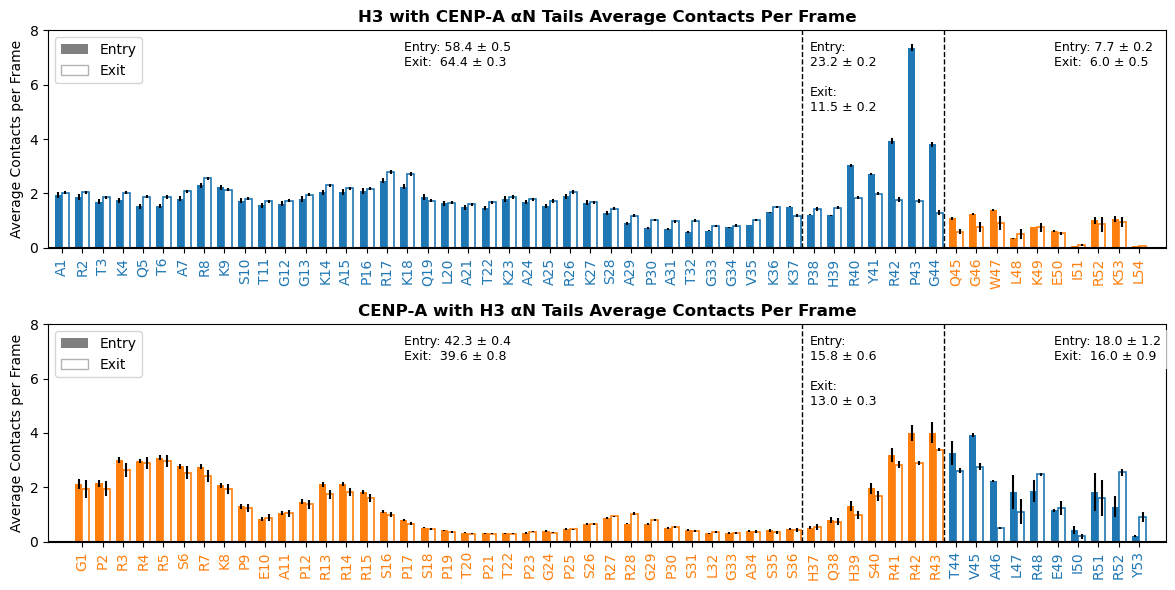

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick marks
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 38
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            if region == "latch":
                # Vertical format for latch only
                text = (
                    f"Entry:\n"
                    f"{entry_val:.1f} ± {entry_sem:.1f}\n\n"
                    f"Exit:\n"
                    f"{exit_val:.1f} ± {exit_sem:.1f}"
                )
            else:
                # Normal format for tails + helix
                text = (
                    f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                    f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
                )

            ax.text(
                xpos,
                y_top,
                text,
                ha='left',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listH3withcenpahelix) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_H3withcenpahelix, ste_entry_H3withcenpahelix = load_tail_data("H3withcenpahelix", "entry")
avg_exit_H3withcenpahelix, ste_exit_H3withcenpahelix = load_tail_data("H3withcenpahelix", "exit")

avg_entry_cenpawithH3helix, ste_entry_cenpawithH3helix = load_tail_data("cenpawithH3helix", "entry")
avg_exit_cenpawithH3helix, ste_exit_cenpawithH3helix = load_tail_data("cenpawithH3helix", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listH3withcenpahelix)

# H3withcenpahelix
avg_entry_H3withcenpahelix_plot = list(avg_entry_H3withcenpahelix)
ste_entry_H3withcenpahelix_plot = list(ste_entry_H3withcenpahelix)
avg_exit_H3withcenpahelix_plot = list(avg_exit_H3withcenpahelix)
ste_exit_H3withcenpahelix_plot = list(ste_exit_H3withcenpahelix)
labels_H3withcenpahelix_plot = list(listH3withcenpahelix)

# cenpawithH3helix (shift)
avg_entry_cenpawithH3helix_plot = [0] + list(avg_entry_cenpawithH3helix)
ste_entry_cenpawithH3helix_plot = [0] + list(ste_entry_cenpawithH3helix)
avg_exit_cenpawithH3helix_plot = [0] + list(avg_exit_cenpawithH3helix)
ste_exit_cenpawithH3helix_plot = [0] + list(ste_exit_cenpawithH3helix)
labels_cenpawithH3helix_plot = [""] + list(listcenpawithH3helix)

highlight_H3withcenpahelix = {i: tab20(2) for i in range(44,54)}
highlight_cenpawithH3helix = {i: tab20(0) for i in range(44,54)}

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# H3withcenpahelix
plot_system(
    axes[0],
    avg_entry_H3withcenpahelix_plot, ste_entry_H3withcenpahelix_plot,
    avg_exit_H3withcenpahelix_plot, ste_exit_H3withcenpahelix_plot,
    labels_H3withcenpahelix_plot, tab20(0),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_H3withcenpahelix,
    subtitle="H3 with CENP-A \u03B1N Tails Average Contacts Per Frame",
    system_name="H3withcenpahelix"
)

# cenpawithH3helix
plot_system(
    axes[1],
    avg_entry_cenpawithH3helix_plot, ste_entry_cenpawithH3helix_plot,
    avg_exit_cenpawithH3helix_plot, ste_exit_cenpawithH3helix_plot,
    labels_cenpawithH3helix_plot, tab20(2),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_cenpawithH3helix,
    subtitle="CENP-A with H3 \u03B1N Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="cenpawithH3helix"
)

plt.tight_layout()
plt.savefig('helix_CG_BYRES_CONTACTS.pdf')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/3003232675.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/3003232675.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


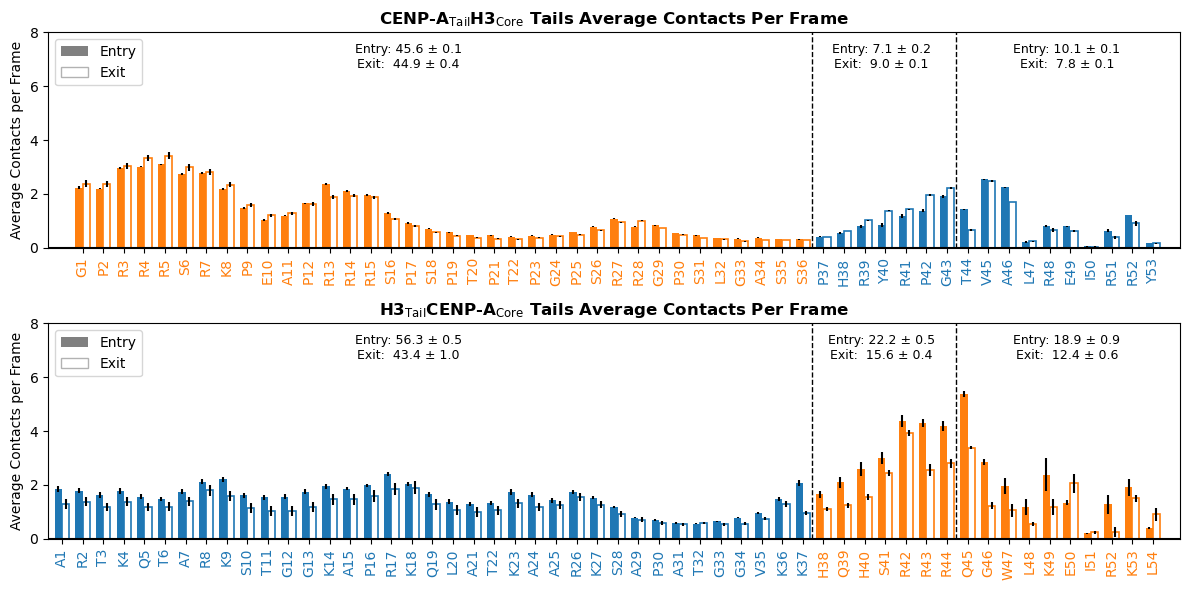

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick marks
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(liststcenpacore) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_stH3core, ste_entry_stH3core = load_tail_data("stH3core", "entry")
avg_exit_stH3core, ste_exit_stH3core = load_tail_data("stH3core", "exit")

avg_entry_stcenpacore, ste_entry_stcenpacore = load_tail_data("stcenpacore", "entry")
avg_exit_stcenpacore, ste_exit_stcenpacore = load_tail_data("stcenpacore", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(liststcenpacore)

# stH3core (shift)
avg_entry_stH3core_plot = [0] + list(avg_entry_stH3core)
ste_entry_stH3core_plot = [0] + list(ste_entry_stH3core)
avg_exit_stH3core_plot = [0] + list(avg_exit_stH3core)
ste_exit_stH3core_plot = [0] + list(ste_exit_stH3core)
labels_stH3core_plot = [""] + list(liststH3core)

# stcenpacore
avg_entry_stcenpacore_plot = list(avg_entry_stcenpacore)
ste_entry_stcenpacore_plot = list(ste_entry_stcenpacore)
avg_exit_stcenpacore_plot = list(avg_exit_stcenpacore)
ste_exit_stcenpacore_plot = list(ste_exit_stcenpacore)
labels_stcenpacore_plot = list(liststcenpacore)

highlight_stH3core = {i: tab20(2) for i in range(1,37)}
highlight_stcenpacore = {i: tab20(0) for i in range(0,37)}

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# stH3core
plot_system(
    axes[0],
    avg_entry_stH3core_plot, ste_entry_stH3core_plot,
    avg_exit_stH3core_plot, ste_exit_stH3core_plot,
    labels_stH3core_plot, tab20(0),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_stH3core,
    subtitle=r"CENP-A$_{\mathrm{Tail}}$H3$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="stH3core"
)

# stcenpacore
plot_system(
    axes[1],
    avg_entry_stcenpacore_plot, ste_entry_stcenpacore_plot,
    avg_exit_stcenpacore_plot, ste_exit_stcenpacore_plot,
    labels_stcenpacore_plot, tab20(2),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_stcenpacore,
    subtitle=r"H3$_{\mathrm{Tail}}$CENP-A$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    system_name="stcenpacore"
)

plt.tight_layout()
plt.savefig('tail_CG_BYRES_CONTACTS.pdf')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/304391690.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/304391690.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


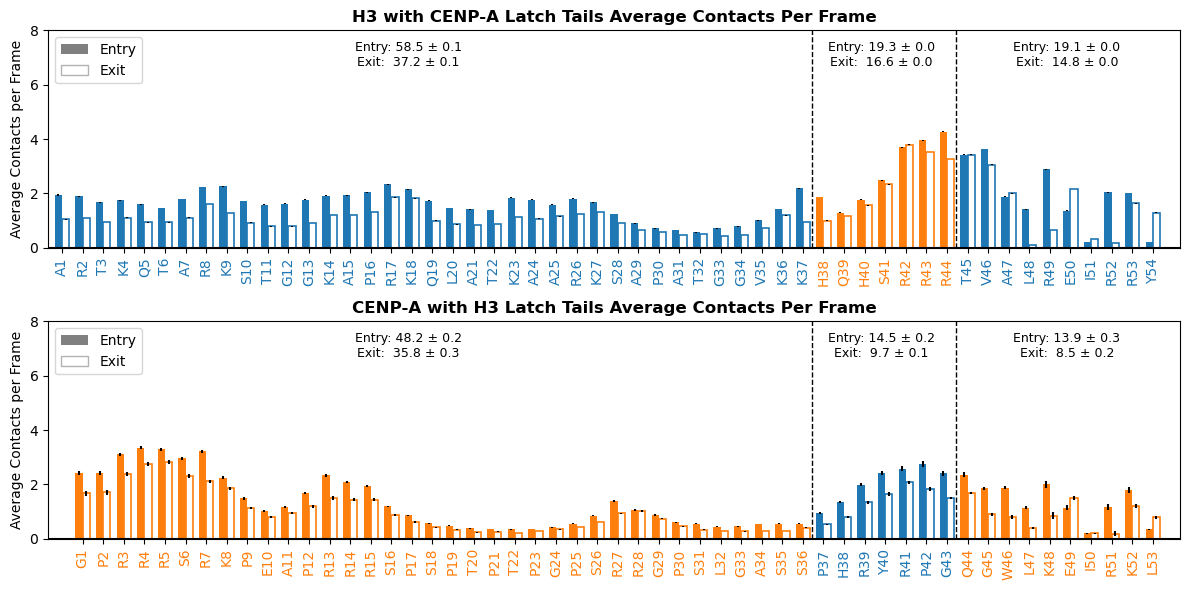

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick marks
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listH3withcenpalatch) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_H3withcenpalatch, ste_entry_H3withcenpalatch = load_tail_data("H3withcenpalatch", "entry")
avg_exit_H3withcenpalatch, ste_exit_H3withcenpalatch = load_tail_data("H3withcenpalatch", "exit")

avg_entry_cenpawithH3latch, ste_entry_cenpawithH3latch = load_tail_data("cenpawithH3latch", "entry")
avg_exit_cenpawithH3latch, ste_exit_cenpawithH3latch = load_tail_data("cenpawithH3latch", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listH3withcenpalatch)

# H3withcenpalatch
avg_entry_H3withcenpalatch_plot = list(avg_entry_H3withcenpalatch)
ste_entry_H3withcenpalatch_plot = list(ste_entry_H3withcenpalatch)
avg_exit_H3withcenpalatch_plot = list(avg_exit_H3withcenpalatch)
ste_exit_H3withcenpalatch_plot = list(ste_exit_H3withcenpalatch)
labels_H3withcenpalatch_plot = list(listH3withcenpalatch)

# cenpawithH3latch (shift)
avg_entry_cenpawithH3latch_plot = [0] + list(avg_entry_cenpawithH3latch)
ste_entry_cenpawithH3latch_plot = [0] + list(ste_entry_cenpawithH3latch)
avg_exit_cenpawithH3latch_plot = [0] + list(avg_exit_cenpawithH3latch)
ste_exit_cenpawithH3latch_plot = [0] + list(ste_exit_cenpawithH3latch)
labels_cenpawithH3latch_plot = [""] + list(listcenpawithH3latch)

highlight_H3withcenpalatch = {i: tab20(2) for i in range(37,44)}
highlight_cenpawithH3latch = {i: tab20(0) for i in range(37,44)}

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# H3withcenpalatch
plot_system(
    axes[0],
    avg_entry_H3withcenpalatch_plot, ste_entry_H3withcenpalatch_plot,
    avg_exit_H3withcenpalatch_plot, ste_exit_H3withcenpalatch_plot,
    labels_H3withcenpalatch_plot, tab20(0),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_H3withcenpalatch,
    subtitle="H3 with CENP-A Latch Tails Average Contacts Per Frame",
    system_name="H3withcenpalatch"
)

# cenpawithH3latch
plot_system(
    axes[1],
    avg_entry_cenpawithH3latch_plot, ste_entry_cenpawithH3latch_plot,
    avg_exit_cenpawithH3latch_plot, ste_exit_cenpawithH3latch_plot,
    labels_cenpawithH3latch_plot, tab20(2),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_cenpawithH3latch,
    subtitle="CENP-A with H3 Latch Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="cenpawithH3latch"
)

plt.tight_layout()
plt.savefig('latch_CG_BYRES_CONTACTS.pdf')
plt.show()

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/580194562.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_47472/580194562.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


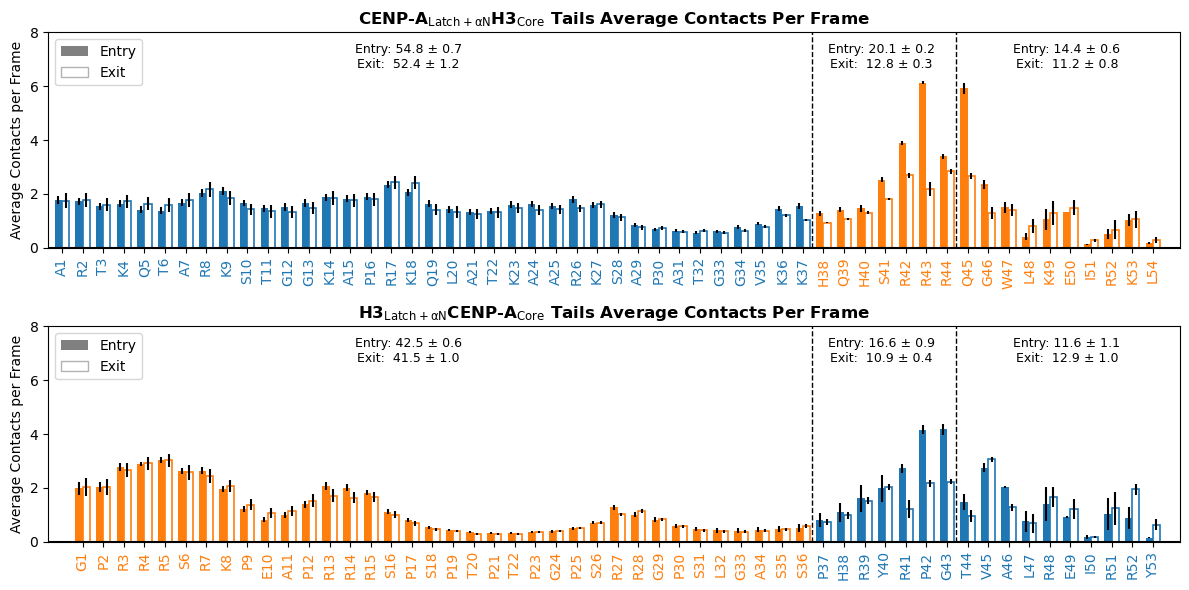

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system, tail_type):
    path = os.path.join(system, f"{system}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None,
                subtitle=None, remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick marks
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listH3withcenpa_latch_helix) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_H3withcenpa_latch_helix, ste_entry_H3withcenpa_latch_helix = load_tail_data("H3withcenpa_latch_helix", "entry")
avg_exit_H3withcenpa_latch_helix, ste_exit_H3withcenpa_latch_helix = load_tail_data("H3withcenpa_latch_helix", "exit")

avg_entry_cenpawithH3_latch_helix, ste_entry_cenpawithH3_latch_helix = load_tail_data("cenpawithH3_latch_helix", "entry")
avg_exit_cenpawithH3_latch_helix, ste_exit_cenpawithH3_latch_helix = load_tail_data("cenpawithH3_latch_helix", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listH3withcenpa_latch_helix)

# H3withcenpa_latch_helix
avg_entry_H3withcenpa_latch_helix_plot = list(avg_entry_H3withcenpa_latch_helix)
ste_entry_H3withcenpa_latch_helix_plot = list(ste_entry_H3withcenpa_latch_helix)
avg_exit_H3withcenpa_latch_helix_plot = list(avg_exit_H3withcenpa_latch_helix)
ste_exit_H3withcenpa_latch_helix_plot = list(ste_exit_H3withcenpa_latch_helix)
labels_H3withcenpa_latch_helix_plot = list(listH3withcenpa_latch_helix)

# cenpawithH3_latch_helix (shift)
avg_entry_cenpawithH3_latch_helix_plot = [0] + list(avg_entry_cenpawithH3_latch_helix)
ste_entry_cenpawithH3_latch_helix_plot = [0] + list(ste_entry_cenpawithH3_latch_helix)
avg_exit_cenpawithH3_latch_helix_plot = [0] + list(avg_exit_cenpawithH3_latch_helix)
ste_exit_cenpawithH3_latch_helix_plot = [0] + list(ste_exit_cenpawithH3_latch_helix)
labels_cenpawithH3_latch_helix_plot = [""] + list(listcenpawithH3_latch_helix)

highlight_H3withcenpa_latch_helix = {i: tab20(2) for i in range(37,54)}
highlight_cenpawithH3_latch_helix = {i: tab20(0) for i in range(37,54)}

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# H3withcenpa_latch_helix
plot_system(
    axes[0],
    avg_entry_H3withcenpa_latch_helix_plot, ste_entry_H3withcenpa_latch_helix_plot,
    avg_exit_H3withcenpa_latch_helix_plot, ste_exit_H3withcenpa_latch_helix_plot,
    labels_H3withcenpa_latch_helix_plot, tab20(0),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_H3withcenpa_latch_helix,
    subtitle=r"CENP-A$_{\mathrm{Latch+\alpha N}}$H3$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    system_name="H3withcenpa_latch_helix"
)

# cenpawithH3_latch_helix
plot_system(
    axes[1],
    avg_entry_cenpawithH3_latch_helix_plot, ste_entry_cenpawithH3_latch_helix_plot,
    avg_exit_cenpawithH3_latch_helix_plot, ste_exit_cenpawithH3_latch_helix_plot,
    labels_cenpawithH3_latch_helix_plot, tab20(2),
    entry_alpha=1.0, exit_alpha=0.6,
    highlight=highlight_cenpawithH3_latch_helix,
    subtitle=r"H3$_{\mathrm{Latch+\alpha N}}$CENP-A$_{\mathrm{Core}}$ Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="cenpawithH3_latch_helix"
)

plt.tight_layout()
plt.savefig('latch+helix_CG_BYRES_CONTACTS.pdf')
plt.show()